In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
from myGP_torch import *
from pyswarms.single.global_best import GlobalBestPSO

In [28]:
data = np.loadtxt("output/05-01-2025_11-01-56_DLK_1.0_3.0_10000.0.csv")
train_Z = data[:,:2]
train_T = data[:,2:]
training_params = {"max_iter": 200, "optimizer": "Adam", "num_restarts": 15}
NN_params = {"depth": 4, "neurons": 64}
GP_s = moGP_torch(train_T, train_Z, kernel="DLK", training_params=training_params)


In [29]:
# data = np.loadtxt("output/05-01-2025_10-59-23_Matern_1.0_3.0_10000.0.csv")
# train_Z = data[:,:2]
# train_T = data[:,2:]
# training_params = {"max_iter": 200, "optimizer": "Adam", "num_restarts": 5}
# GP_s = moGP_torch(train_T, train_Z, kernel="Matern32", training_params=training_params)


In [30]:
n_pts = 101
# Bounds on the inputs variable
var_bounds = [(-2., 2.), (-2., 2.)]
var_set = linearly_spaced_combinations([var_bounds[0], var_bounds[1]], n_pts)
# Bounds on the context variable
ctx_bounds = [(-2., 2.), (-2., 2.)]
ctx_set = linearly_spaced_combinations([ctx_bounds[0], ctx_bounds[1]], n_pts)

# Make prediction
W, C = GP_s.predict(ctx_set)
W1 = W[:,0]; W2 = W[:,1]

2025-05-01 15:14:50,309 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:50,309 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:50,310 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:50,310 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:50,311 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:50,311 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:50,315 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:50,324 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:50,324 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New R

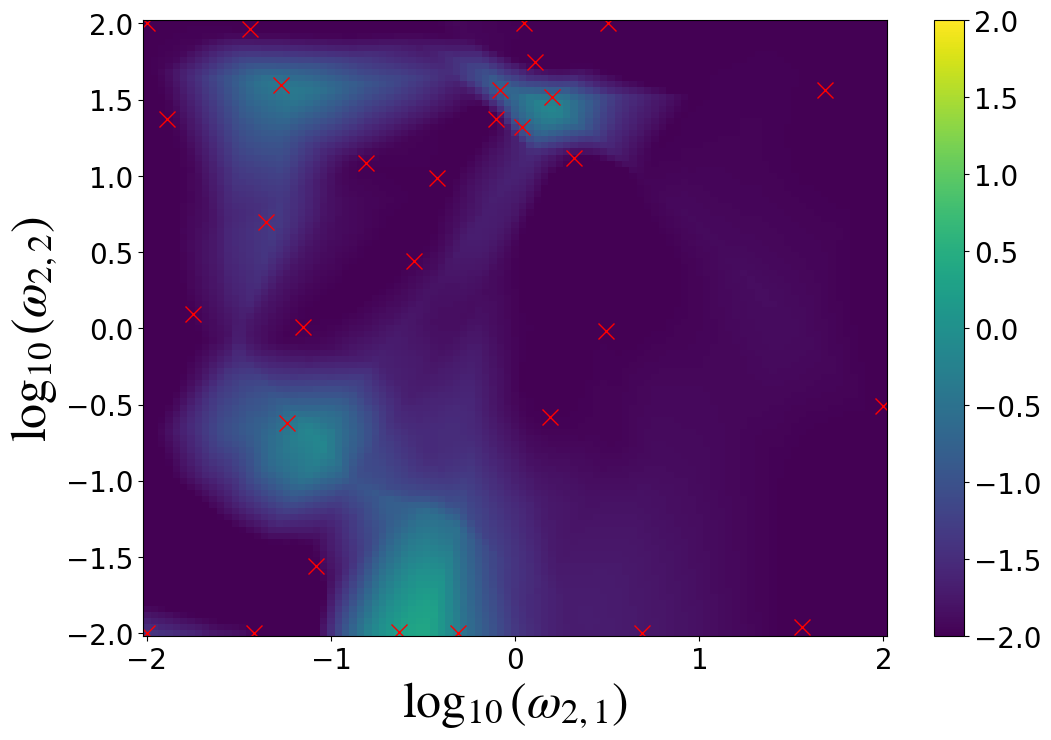

In [31]:
%matplotlib inline
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['font.size'] = '20'

fig = plt.figure(figsize=(12,8))

plt.pcolormesh(ctx_set[:,0].reshape(n_pts,n_pts), ctx_set[:,1].reshape(n_pts,n_pts), W1.reshape(n_pts,n_pts), vmin = -2.0, vmax = 2.0)
plt.plot(data[:,2], data[:,3], 'rx', markersize = 12)
plt.colorbar()
plt.xlabel(r'$\log_{10}(\omega_{2,1})$', fontsize=36)
plt.ylabel(r'$\log_{10}(\omega_{2,2})$', fontsize=36)
filename = 'dlk_w1.pdf'
plt.savefig(filename, bbox_inches='tight') 

2025-05-01 15:14:51,138 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:51,139 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:51,140 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:51,140 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:51,141 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:51,142 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:51,148 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:51,164 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New Roman' not found.
2025-05-01 15:14:51,165 - matplotlib.font_manager - WARNING - findfont: Font family 'Times New R

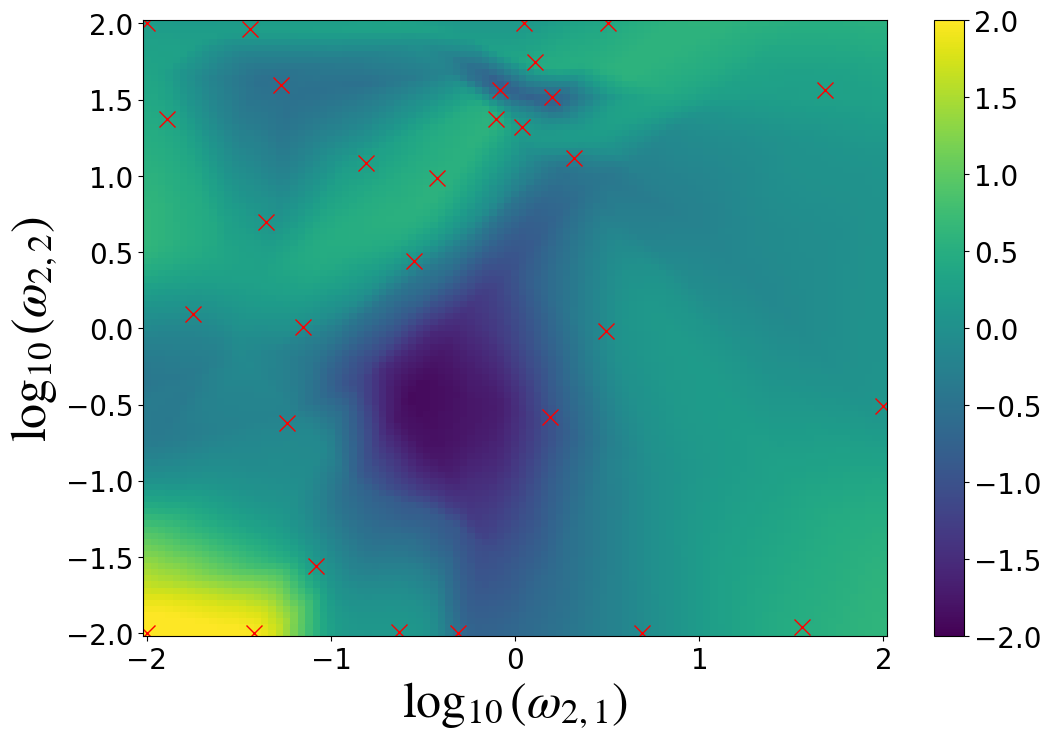

In [32]:
%matplotlib inline
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['font.size'] = '20'
fig = plt.figure(figsize=(12,8))

plt.pcolormesh(ctx_set[:,0].reshape(n_pts,n_pts), ctx_set[:,1].reshape(n_pts,n_pts), W2.reshape(n_pts,n_pts), vmin = -2.0, vmax = 2.0)
plt.plot(data[:,2], data[:,3], 'rx', markersize = 12)
plt.colorbar()
plt.xlabel(r'$\log_{10}(\omega_{2,1})$', fontsize=36)
plt.ylabel(r'$\log_{10}(\omega_{2,2})$', fontsize=36)
filename = 'dlk_w2.pdf'
plt.savefig(filename, bbox_inches='tight') 
